In [1]:
# Install library timm (PyTorch Image Models - Gudangnya Swin/ViT)
!pip install -q timm split-folders

In [2]:
import timm
print(f"✅ Timm version: {timm.__version__}")

✅ Timm version: 1.0.24


In [3]:
# ====================================================
# BLOCK 1: SETUP ENVIRONMENT & LIBRARY
# ====================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import timm
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, r2_score
import copy
from PIL import Image
import torch.nn.functional as F # Untuk fungsi softmax

# Cek Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")

# Setup Folder
def find_train_folder(start_dir):
    for root, dirs, files in os.walk(start_dir):
        if 'train' in dirs: return root
    return None

INPUT_ROOT = find_train_folder("/kaggle/input")
WORKING_DIR = "/kaggle/working/dataset_final_20class"

if not os.path.exists(WORKING_DIR):
    print(f"🚀 Copying Dataset...")
    shutil.copytree(os.path.join(INPUT_ROOT, "train"), os.path.join(WORKING_DIR, "train"))
    shutil.copytree(os.path.join(INPUT_ROOT, "val"), os.path.join(WORKING_DIR, "val"))
    if os.path.exists(os.path.join(INPUT_ROOT, "test")):
        shutil.copytree(os.path.join(INPUT_ROOT, "test"), os.path.join(WORKING_DIR, "test"))
else:
    print("✅ Dataset Ready.")

TRAIN_DIR = os.path.join(WORKING_DIR, 'train')
VAL_DIR = os.path.join(WORKING_DIR, 'val')
TEST_DIR = os.path.join(WORKING_DIR, 'test')

✅ Device: cuda
🚀 Copying Dataset...


In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm 

print("⏳ Menghitung Mean dan Std khusus dari Dataset RSNA-mu...")

# 1. Load dataset TANPA augmentasi & TANPA normalize
# Hanya resize dan ubah ke Tensor 
calc_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

calc_dataset = datasets.ImageFolder(TRAIN_DIR, transform=calc_transforms)
calc_loader = DataLoader(calc_dataset, batch_size=64, shuffle=False, num_workers=2)

def calculate_mean_std(loader):
    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    
    for data, _ in tqdm(loader, desc="Calculating"):
        # data format: [batch_size, channels(3), height, width]
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data**2, dim=[0, 2, 3])
        num_batches += 1
        
    mean = channels_sum / num_batches
    # Rumus Varians: E[X^2] - (E[X])^2, lalu diakar jadi Std
    std = (channels_squared_sum / num_batches - mean**2)**0.5
    return mean, std

# 2. Eksekusi Perhitungan
custom_mean, custom_std = calculate_mean_std(calc_loader)

print("\n✅ SELESAI! new mean dan std baru:")
print(f"Mean Baru: {[round(x.item(), 4) for x in custom_mean]}")
print(f"Std Baru : {[round(x.item(), 4) for x in custom_std]}")

⏳ Menghitung Mean dan Std khusus dari Dataset RSNA-mu...


Calculating: 100%|██████████| 158/158 [03:21<00:00,  1.27s/it]


✅ SELESAI! new mean dan std baru:
Mean Baru: [0.1823, 0.1823, 0.1823]
Std Baru : [0.1924, 0.1924, 0.1924]


✅ Test Loader Created.
📸 Preview Augmentasi V6 (Sharpness + Contrast):


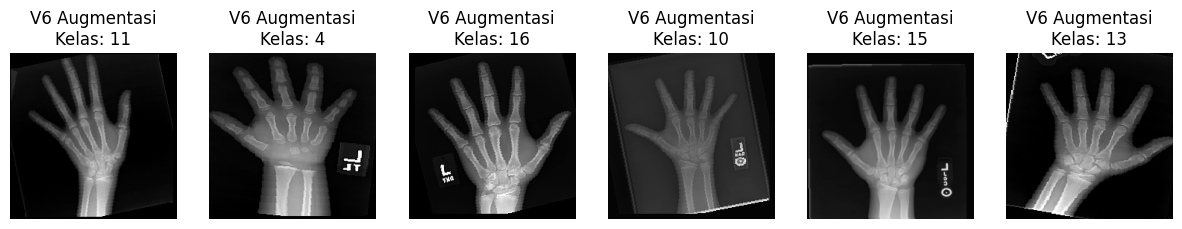

In [5]:
# ====================================================
# BLOCK 2: AUGMENTASI & VISUALISASI INPUT
# ====================================================
IMG_SIZE = 224
BATCH_SIZE = 32

# --- PERUBAHAN 1: AUGMENTASI JURNAL ---
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),

    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3), # Pertajam tepi tulang
    transforms.RandomAutocontrast(p=0.3), # Perjelas kalsifikasi

    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Jitter sedikit dinaikkan
    
    transforms.ToTensor(),
    # Pakai Mean dan Std RSNA
    transforms.Normalize([0.1823, 0.1823, 0.1823], [0.1924, 0.1924, 0.1924])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    # Pakai Mean dan Std RSNA
    transforms.Normalize([0.1823, 0.1823, 0.1823], [0.1924, 0.1924, 0.1924])
])

# Load Dataset
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transforms)

# Dataloader (Tanpa WeightedSampler agar stabil seperti V5)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Test Loader (PENTING BUAT EVALUASI)
if os.path.exists(TEST_DIR):
    test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_transforms)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    print("✅ Test Loader Created.")

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

# --- VISUALISASI AUGMENTASI V6 ---
def show_augmented_samples(loader):
    images, labels = next(iter(loader))
    plt.figure(figsize=(15, 5))
    for i in range(6):
        ax = plt.subplot(1, 6, i + 1)
        img = images[i].numpy().transpose((1, 2, 0))
        mean = np.array([0.1823, 0.1823, 0.1823])
        std = np.array([0.1924, 0.1924, 0.1924])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f"V6 Augmentasi\nKelas: {class_names[labels[i]]}")
        plt.axis("off")
    plt.show()

print("📸 Preview Augmentasi V6 (Sharpness + Contrast):")
show_augmented_samples(train_loader)

In [6]:
print("⬇️ Download Swin Tiny...")
model_base = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0, global_pool='avg')

head_v6 = nn.Sequential(
    nn.Linear(model_base.num_features, 512),
    nn.BatchNorm1d(512), # Cukup satu BN disini
    nn.ReLU(),
    nn.Dropout(0.5),     # Dropout standar 0.5
    nn.Linear(512, len(train_dataset.classes))
)

class SwinWrapper(nn.Module):
    def __init__(self, base_model, head):
        super().__init__()
        self.base_model = base_model
        self.head = head
    
    def forward(self, x): 
        x = self.base_model(x)
        x = self.head(x)
        return x

model = SwinWrapper(model_base, head_v6).to(device)
print("✅ Model V6 Ready (Normalisasi new)")

⬇️ Download Swin Tiny...


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ Model V6 Ready (Normalisasi new)


In [7]:
# Config Tetap Sama dengan V5 (Karena V5 sudah stabil)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

def train_v6(model, criterion, optimizer, scheduler, num_epochs):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    print(f"\n🔥 START TRAINING V6 ...")
    print("-" * 75)
    
    for epoch in range(num_epochs):
        # TRAIN
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            
            run_loss += loss.item() * x.size(0)
            _, pred = torch.max(out, 1)
            correct += (pred == y).sum().item()
            total += y.size(0)
        
        train_loss = run_loss / total
        train_acc = correct / total

        # VALIDATION
        model.eval()
        val_loss_run, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_loss_run += loss.item() * x.size(0)
                _, pred = torch.max(out, 1)
                val_correct += (pred == y).sum().item()
                val_total += y.size(0)
        
        val_loss = val_loss_run / val_total
        val_acc = val_correct / val_total
        
        if scheduler: scheduler.step()

        history['train_acc'].append(train_acc); history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)

        # PRINT LENGKAP
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"   Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"   Train Acc : {train_acc:.4f}  | Val Acc : {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), 'swin_v6_normalisasi_new.pth')
            print(f"   💾 New Best: {best_acc:.4f}")
        
        print("-" * 75)

    model.load_state_dict(best_model_wts)
    return model, history

# RUN V6
for param in model.parameters(): param.requires_grad = True
model, history = train_v6(model, criterion, optimizer, scheduler, num_epochs=50)


🔥 START TRAINING V6 ...
---------------------------------------------------------------------------
Epoch 1/50
   Train Loss: 2.6017 | Val Loss: 2.1247
   Train Acc : 0.1708  | Val Acc : 0.2481
   💾 New Best: 0.2481
---------------------------------------------------------------------------
Epoch 2/50
   Train Loss: 2.1849 | Val Loss: 2.1585
   Train Acc : 0.2469  | Val Acc : 0.2774
   💾 New Best: 0.2774
---------------------------------------------------------------------------
Epoch 3/50
   Train Loss: 2.0888 | Val Loss: 1.9336
   Train Acc : 0.2804  | Val Acc : 0.3294
   💾 New Best: 0.3294
---------------------------------------------------------------------------
Epoch 4/50
   Train Loss: 2.0418 | Val Loss: 1.9125
   Train Acc : 0.3013  | Val Acc : 0.3365
   💾 New Best: 0.3365
---------------------------------------------------------------------------
Epoch 5/50
   Train Loss: 2.0104 | Val Loss: 1.8796
   Train Acc : 0.3132  | Val Acc : 0.3559
   💾 New Best: 0.3559
---------------


🔍 EVALUASI FINAL V6 (TEST DATA)...

📊 HASIL V6 Normalisasi baru (FINAL METRICS)
🏆 Top-1 Accuracy:       47.44%
🤝 Tolerance Acc (±1):   86.04%
🥉 Top-3 Accuracy:       88.84%
🏥 MAE (Tahun):          0.7151 Tahun
📅 MAE (Bulan):          8.6 Bulan
⚠️ RMSE (Sensitif):   1.1053 Tahun
📈 R-Squared Score:      0.9032
---------------------------------------------

📄 LAPORAN DETAIL PER KELAS:
              precision    recall  f1-score   support

      Umur 0       0.00      0.00      0.00         2
      Umur 1       0.64      0.82      0.72        11
      Umur 2       0.42      0.59      0.49        17
      Umur 3       0.48      0.38      0.43        26
      Umur 4       0.41      0.37      0.39        38
      Umur 5       0.48      0.45      0.46        58
      Umur 6       0.43      0.56      0.49        82
      Umur 7       0.50      0.47      0.49       108
      Umur 8       0.42      0.40      0.41        97
      Umur 9       0.29      0.18      0.23        49
     Umur 10       

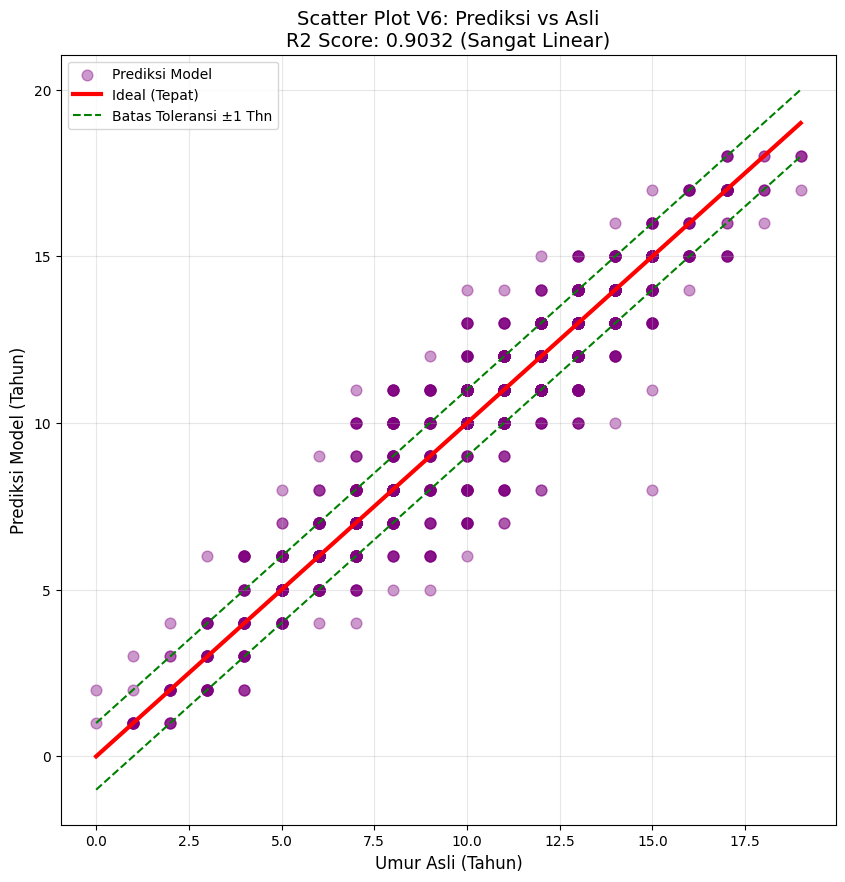

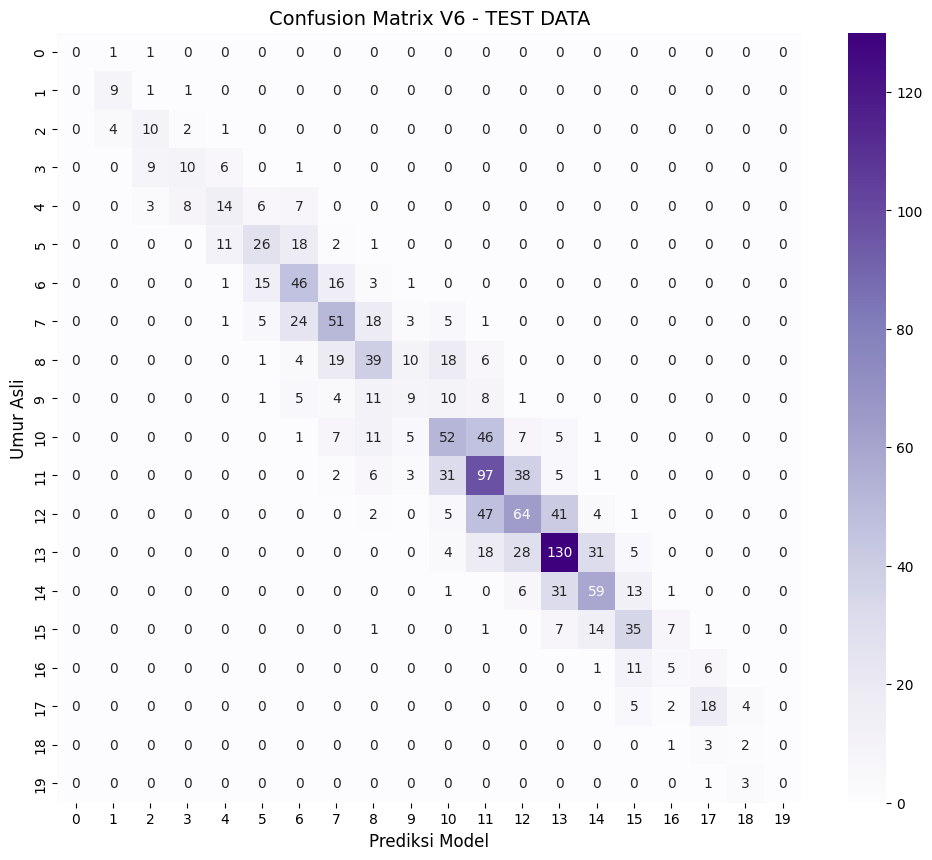

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, confusion_matrix
# ====================================================
# BLOCK 6: EVALUASI LENGKAP V6 (SCATTER + REPORT)
# ====================================================
def evaluate_v6_complete(model, loader, dataset_name="DATA TEST"):
    model.eval()
    
    # Mapping Kelas
    real_ages = [int(x) for x in class_names]
    real_ages_tensor = torch.tensor(real_ages).to(device)
    
    all_preds, all_labels = [], []
    correct_top3, total = 0, 0
    
    print(f"\n🔍 EVALUASI FINAL V6 ({dataset_name})...")
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            
            # Top-1
            _, pred_idx = torch.max(out, 1)
            
            # Top-3
            _, top3_idx = torch.topk(out, 3, dim=1)
            for i in range(y.size(0)):
                if y[i] in top3_idx[i]: correct_top3 += 1
            
            pred_age = real_ages_tensor[pred_idx]
            true_age = real_ages_tensor[y]
            all_preds.extend(pred_age.cpu().numpy())
            all_labels.extend(true_age.cpu().numpy())
            total += y.size(0)
            
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    # Metrik Utama
    exact = np.mean(y_true == y_pred) * 100
    tol = np.mean(np.abs(y_true - y_pred) <= 1) * 100
    top3 = (correct_top3 / total) * 100
    r2 = r2_score(y_true, y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    # [BARU] RMSE (Hukuman untuk error besar)
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    
    print("\n" + "="*45)
    print(f"📊 HASIL V6 Normalisasi baru (FINAL METRICS)")
    print("="*45)
    print(f"🏆 Top-1 Accuracy:       {exact:.2f}%")
    print(f"🤝 Tolerance Acc (±1):   {tol:.2f}%")
    print(f"🥉 Top-3 Accuracy:       {top3:.2f}%")
    print(f"🏥 MAE (Tahun):          {mae:.4f} Tahun")
    print(f"📅 MAE (Bulan):          {mae*12:.1f} Bulan")
    print(f"⚠️ RMSE (Sensitif):   {rmse:.4f} Tahun") # Semakin kecil semakin bagus
    print(f"📈 R-Squared Score:      {r2:.4f}")
    print("-" * 45)
    
    # 1. Classification Report (Recall, Precision, F1)
    sorted_classes = sorted(list(set(real_ages)))
    target_names = [f"Umur {i}" for i in sorted_classes]
    print("\n📄 LAPORAN DETAIL PER KELAS:")
    print(classification_report(y_true, y_pred, labels=sorted_classes, target_names=target_names, zero_division=0))
    
    # 2. Scatter Plot V6
    plt.figure(figsize=(10, 10))
    # Plot titik dengan transparansi biar kelihatan numpuknya dimana
    plt.scatter(y_true, y_pred, alpha=0.4, color='purple', s=60, label='Prediksi Model')
    
    # Garis Ideal
    plt.plot([0, 19], [0, 19], 'r-', linewidth=3, label='Ideal (Tepat)')
    # Garis Toleransi
    plt.plot([0, 19], [-1, 18], 'g--', label='Batas Toleransi ±1 Thn')
    plt.plot([0, 19], [1, 20], 'g--')
    
    plt.title(f"Scatter Plot V6: Prediksi vs Asli\nR2 Score: {r2:.4f} (Sangat Linear)", fontsize=14)
    plt.xlabel("Umur Asli (Tahun)", fontsize=12)
    plt.ylabel("Prediksi Model (Tahun)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("scatter_v6normalisasi_new.png")
    plt.show()
    
    # 3. Confusion Matrix V6
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(y_true, y_pred, labels=sorted_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=sorted_classes, yticklabels=sorted_classes)
    plt.title(f"Confusion Matrix V6 - {dataset_name}", fontsize=14)
    plt.xlabel("Prediksi Model", fontsize=12)
    plt.ylabel("Umur Asli", fontsize=12)
    plt.savefig("cm_v6normalisasi_new.png")
    plt.show()

# EKSEKUSI
if 'test_loader' in globals():
    evaluate_v6_complete(model, test_loader, "TEST DATA")
else:
    evaluate_v6_complete(model, val_loader, "VALIDATION DATA")

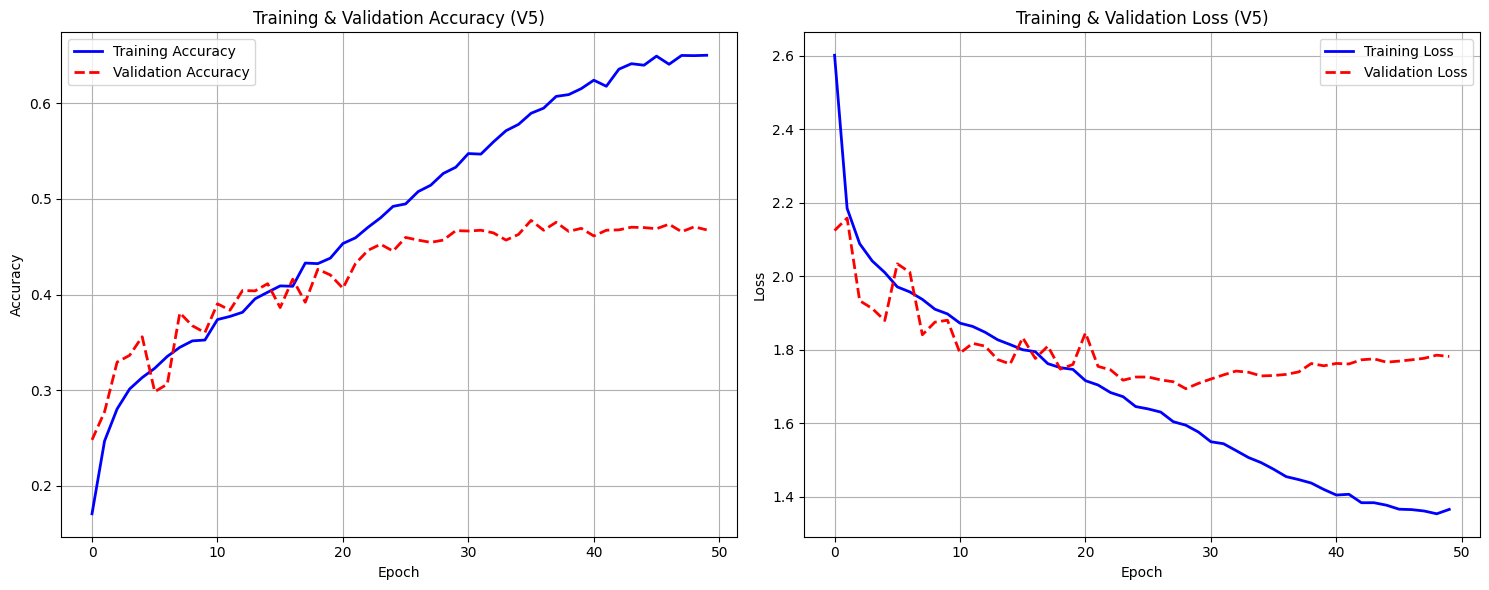

✅ Grafik tersimpan sebagai 'grafik_v6_normalisasi_new.png'


In [9]:
# ====================================================
# BLOCK 6: VISUALISASI GRAFIK
# ====================================================
acc = history['train_acc']
val_acc = history['val_acc']
loss = history['train_loss']
val_loss = history['val_loss']

plt.figure(figsize=(15, 6))

# Grafik 1: Accuracy (Harusnya naik bareng)
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(val_acc, label='Validation Accuracy', color='red', linewidth=2, linestyle='--')
plt.title('Training & Validation Accuracy (V5)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)

# Grafik 2: Loss (Harusnya turun bareng)
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(val_loss, label='Validation Loss', color='red', linewidth=2, linestyle='--')
plt.title('Training & Validation Loss (V5)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig("grafik_v6_normalisasi_new.png")
plt.show()
print("✅ Grafik tersimpan sebagai 'grafik_v6_normalisasi_new.png'")


🔍 Random Check 5 Gambar...


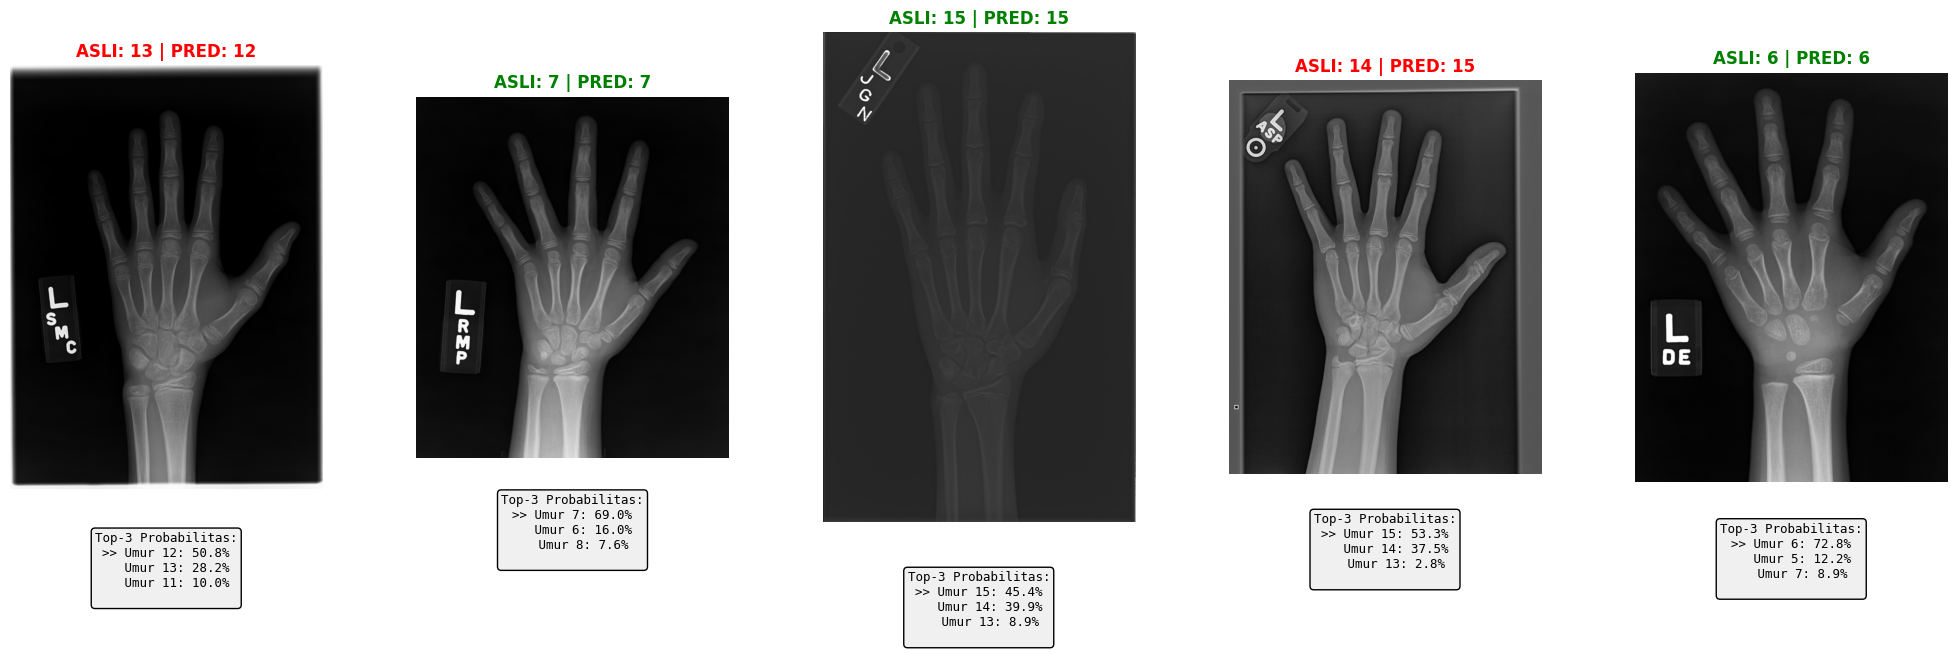

In [10]:
import random

def predict_5_random_images(model, dataset, class_names, device):
    fig, axes = plt.subplots(1, 5, figsize=(25, 8))
    plt.subplots_adjust(wspace=0.3)
    print("\n🔍 Random Check 5 Gambar...")

    for i in range(5):
        ax = axes[i]
        random_idx = random.randint(0, len(dataset) - 1)
        img_path, label_idx = dataset.samples[random_idx]
        actual_age = class_names[label_idx]
        
        try:
            pil_img = Image.open(img_path).convert('RGB')
            # Pakai val_transforms (jangan yg ada augmentasi acaknya)
            img_tensor = val_transforms(pil_img).unsqueeze(0).to(device)
            
            model.eval()
            with torch.no_grad():
                outputs = model(img_tensor)
                probs = F.softmax(outputs, dim=1)
                
                # Top-1
                conf, pred_idx = torch.max(probs, 1)
                pred_age = class_names[pred_idx.item()]
                
                # Top-3
                top3_prob, top3_idx = torch.topk(probs, 3)
        except Exception as e:
            print(f"Error: {e}")
            continue

        # Visualisasi
        ax.imshow(pil_img)
        ax.axis('off')
        
        is_correct = (str(pred_age) == str(actual_age))
        status_color = 'green' if is_correct else 'red'
        
        ax.set_title(f"ASLI: {actual_age} | PRED: {pred_age}", color=status_color, fontweight='bold')
        
        # Detail Text
        detail = "Top-3 Probabilitas:\n"
        for j in range(3):
            idx = top3_idx[0][j].item()
            age_lbl = class_names[idx]
            scr = top3_prob[0][j].item() * 100
            mark = ">> " if j == 0 else "   "
            detail += f"{mark}Umur {age_lbl}: {scr:.1f}%\n"
            
        ax.text(0.5, -0.1, detail, transform=ax.transAxes, ha='center', va='top', 
                fontsize=9, family='monospace', bbox=dict(boxstyle="round", fc="#f0f0f0"))

    plt.show()

# Panggil Fungsi
if 'test_dataset' in globals():
    predict_5_random_images(model, test_dataset, class_names, device)
else:
    predict_5_random_images(model, val_dataset, class_names, device)